<a href="https://colab.research.google.com/github/JoudySaleh-IT/IT461-MovieGenreClassification/blob/main/movie_genre_classification_finalized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Genre Classification from Plot Summaries
### IT461 Practical Machine Learning Project
This notebook presents an end-to-end workflow for movie genre classification using textual plot summaries.

In [1]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

import joblib

# 1. Check Available Files
In this section, we verify that the required dataset files are available in the working directory.

In [2]:
!ls -lh

total 101M
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data
-rw-r--r-- 1 root root  34M May  6 11:35 test_data_solution.txt
-rw-r--r-- 1 root root  34M May  6 11:35 test_data.txt
-rw-r--r-- 1 root root  34M May  6 11:35 train_data.txt


# 2. Preview Raw Training Data
Before loading the dataset formally, we inspect a few raw lines to understand the original file format.

In [3]:
with open("train_data.txt", "r", encoding="latin-1") as f:
    for i in range(5):
        print(repr(f.readline()))

'1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.\n'
'2 ::: Cupid (1997) ::: thriller ::: A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.\n'
'3 ::: Young, Wild and Wonderful (1980) ::: adult ::: As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspect t

# 3. Define Data Loading Functions
These helper functions read the training, test, and test solution files and convert them into pandas DataFrames.

In [4]:
def load_train_data(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=3)
            if len(parts) == 4:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Title", "Genre", "Description"])


def load_test_data(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=2)
            if len(parts) == 3:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Title", "Description"])


def load_test_solution(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=1)
            if len(parts) == 2:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Genre"])

# 4. Load the Dataset
We now load the training, test, and test-solution files into DataFrames.

In [5]:
train_df = load_train_data("train_data.txt")
test_df = load_test_data("test_data.txt")
test_solution_df = load_test_solution("test_data_solution.txt")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test solution shape:", test_solution_df.shape)

Train shape: (54214, 4)
Test shape: (54200, 3)
Test solution shape: (54200, 2)


# 5. Inspect the Training Data
We inspect the first few rows to understand the dataset structure and verify that it was loaded correctly.

In [6]:
train_df.head()

,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# 6. Dataset Information and Missing Values
This section shows the data types, missing values, and the number of unique genre classes.

In [7]:
print(train_df.info())
print("\nMissing values:\n", train_df.isnull().sum())
print("\nNumber of unique genres:", train_df["Genre"].nunique())
print("\nGenres:\n", sorted(train_df["Genre"].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  object
 1   Title        54214 non-null  object
 2   Genre        54214 non-null  object
 3   Description  54214 non-null  object
dtypes: object(4)
memory usage: 1.7+ MB
None

Missing values:
 ID             0
Title          0
Genre          0
Description    0
dtype: int64

Number of unique genres: 27

Genres:
 ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


# 7. Summary Statistics
To better understand the dataset, we present key summary statistics describing its structure and scale.

In [8]:
summary_stats = pd.DataFrame({
    "Attribute": [
        "Task Type",
        "Number of Training Examples",
        "Number of Test Examples",
        "Number of Classes (Genres)",
        "Input Feature Type",
        "Output Label"
    ],
    "Value": [
        "Multi-class text classification",
        len(train_df),
        len(test_df),
        train_df["Genre"].nunique(),
        "Text (movie plot summary)",
        "Single genre"
    ]
})

summary_stats

,Attribute,Value
0,Task Type,Multi-class text classification
1,Number of Training Examples,54214
2,Number of Test Examples,54200
3,Number of Classes (Genres),27
4,Input Feature Type,Text (movie plot summary)
5,Output Label,Single genre


# 8. Representative Examples
Below are a few representative examples from the training dataset, including movie title, genre, and description.

In [9]:
train_df[["Title", "Genre", "Description"]].head(5)

,Title,Genre,Description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# 9. Text Preprocessing Function
Since machine learning models cannot process raw text directly, we define a cleaning function to normalize the descriptions.

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 10. Apply Text Preprocessing
We apply the preprocessing function to both the training and test descriptions.

In [11]:
train_df["Clean_Title"] = train_df["Title"].apply(clean_text)
train_df["Clean_Description"] = train_df["Description"].apply(clean_text)

test_df["Clean_Title"] = test_df["Title"].apply(clean_text)
test_df["Clean_Description"] = test_df["Description"].apply(clean_text)

train_df["Full_Text"] = train_df["Clean_Title"] + " " + train_df["Clean_Description"]
test_df["Full_Text"] = test_df["Clean_Title"] + " " + test_df["Clean_Description"]

train_df[["Title", "Clean_Title", "Description", "Clean_Description", "Full_Text"]].head()

,Title,Clean_Title,Description,Clean_Description,Full_Text
0,Oscar et la dame rose (2009),oscar et la dame rose,Listening in to a conversation between his doc...,listening in to a conversation between his doc...,oscar et la dame rose listening in to a conver...
1,Cupid (1997),cupid,A brother and sister with a past incestuous re...,a brother and sister with a past incestuous re...,cupid a brother and sister with a past incestu...
2,"Young, Wild and Wonderful (1980)",young wild and wonderful,As the bus empties the students for their fiel...,as the bus empties the students for their fiel...,young wild and wonderful as the bus empties th...
3,The Secret Sin (1915),the secret sin,To help their unemployed father make ends meet...,to help their unemployed father make ends meet...,the secret sin to help their unemployed father...
4,The Unrecovered (2007),the unrecovered,The film's title refers not only to the un-rec...,the films title refers not only to the unrecov...,the unrecovered the films title refers not onl...


# 11. Analyze Description Lengths
We examine the distribution of movie description lengths to better understand variation in input size.

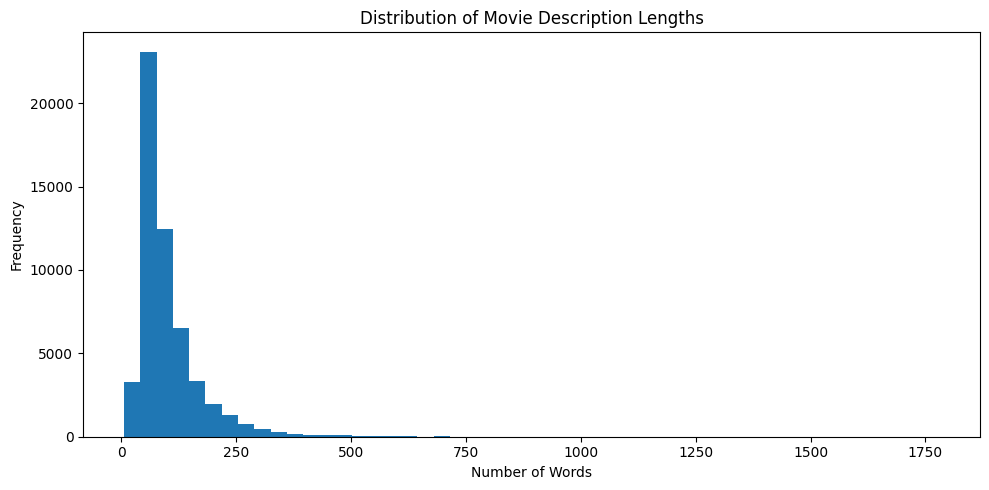

In [12]:
train_df["desc_length"] = train_df["Clean_Description"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
plt.hist(train_df["desc_length"], bins=50)
plt.title("Distribution of Movie Description Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 12. Class Distribution Analysis
This plot shows the distribution of genre classes in the training set and highlights possible class imbalance.

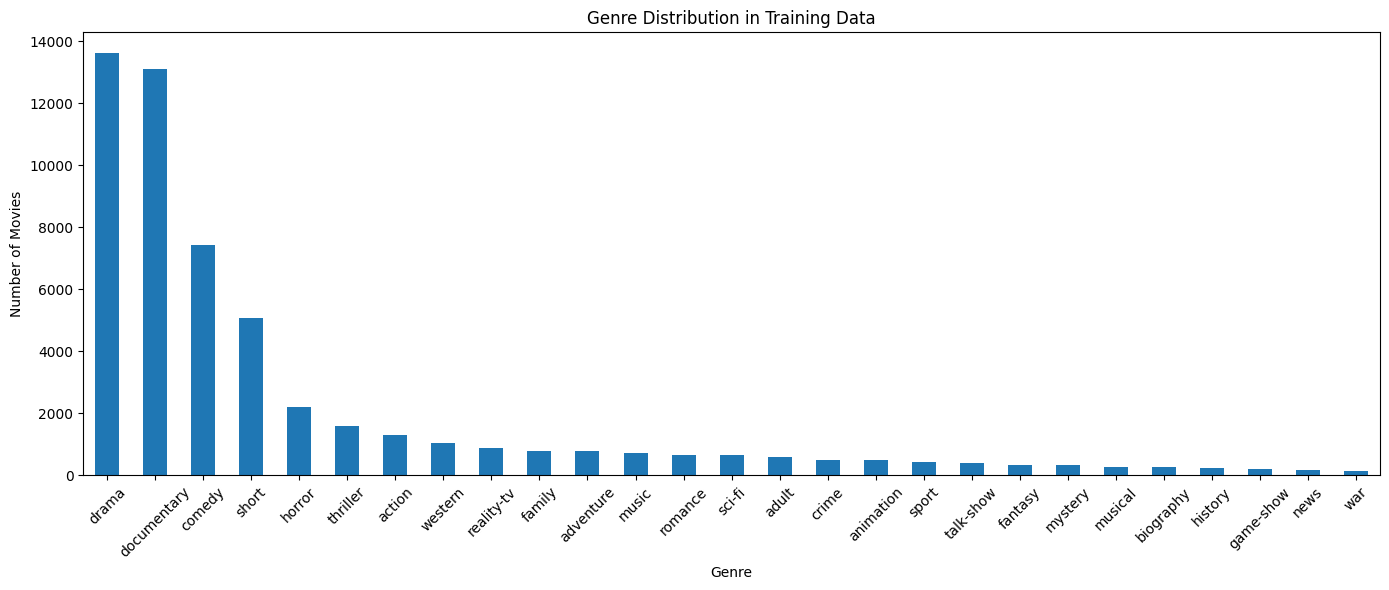

In [13]:
plt.figure(figsize=(14,6))
train_df["Genre"].value_counts().plot(kind="bar")
plt.title("Genre Distribution in Training Data")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Most Common Words in Plot Summaries')

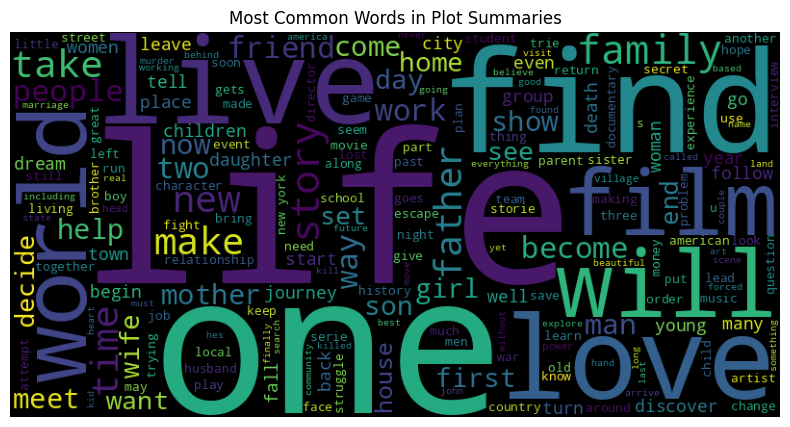

In [14]:
from wordcloud import WordCloud

text = " ".join(train_df["Clean_Description"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Plot Summaries")

# 13. Top Words per Genre
To better understand the textual characteristics of each genre, we display the most frequent words for selected genres.

In [15]:
def top_words_per_class(df, n=10, num_classes=5):
    selected_genres = df["Genre"].value_counts().head(num_classes).index.tolist()

    for genre in selected_genres:
        texts = df[df["Genre"] == genre]["Clean_Description"]
        vectorizer = CountVectorizer(stop_words="english")
        X = vectorizer.fit_transform(texts)

        words = np.array(vectorizer.get_feature_names_out())
        counts = X.sum(axis=0).A1

        top_indices = np.argsort(counts)[-n:][::-1]
        top_words = words[top_indices]

        print(f"\nTop {n} words for genre: {genre}")
        print(top_words)

top_words_per_class(train_df, n=10, num_classes=5)


Top 10 words for genre: drama
['life' 'young' 'love' 'family' 'story' 'man' 'father' 'new' 'mother'
 'lives']

Top 10 words for genre: documentary
['film' 'documentary' 'life' 'world' 'people' 'story' 'new' 'years' 'time'
 'history']

Top 10 words for genre: comedy
['life' 'new' 'love' 'comedy' 'man' 'friends' 'time' 'family' 'young'
 'make']

Top 10 words for genre: short
['film' 'life' 'man' 'young' 'world' 'story' 'time' 'new' 'short' 'day']

Top 10 words for genre: horror
['house' 'young' 'night' 'family' 'friends' 'life' 'group' 'new' 'evil'
 'horror']


# 14. Define Features and Labels
We define the cleaned descriptions as input features (X) and the genre labels as target outputs (y).

In [16]:
X = train_df["Full_Text"]
y = train_df["Genre"]

# 15. Train / Validation Split
In this section, we split the training data into training and validation sets.  
This allows us to evaluate the models on unseen data before using the official test set.  
Because this is a multi-class classification problem, we use a **stratified split** to preserve genre proportions across both subsets.


In [17]:
# Split the data into training and validation sets using stratification
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_valid.shape[0])
print("Number of classes in training set:", y_train.nunique())
print("Number of classes in validation set:", y_valid.nunique())


Training set size: 43371
Validation set size: 10843
Number of classes in training set: 27
Number of classes in validation set: 27


# 16. Feature Extraction using TF-IDF
Machine learning models cannot work directly with raw text, so we convert the cleaned movie descriptions into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.  
TF-IDF is suitable for this task because it gives higher importance to informative words and reduces the influence of very common words.

In this section, we fit the TF-IDF vectorizer on the training set only, then transform both training and validation text.


In [18]:
# Convert text into TF-IDF feature vectors
vectorizer = TfidfVectorizer(
stop_words='english',
    max_features=10000,   # Cap the total vocabulary
    min_df=5,             # Must appear in at least 5 documents
    max_df=0.85,          # Ignore words in >85% of documents
    ngram_range=(1, 2)    # Keep to unigrams and bigrams
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_valid_tfidf = vectorizer.transform(X_valid)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))


X_train_tfidf shape: (43371, 10000)
X_valid_tfidf shape: (10843, 10000)
Vocabulary size: 10000


# 17. Evaluation Helper Functions
To keep the notebook organized and avoid repeating code, we define helper functions for model evaluation.  
These functions compute the main classification metrics and display a detailed classification report.

The metrics used are:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Because the dataset may be imbalanced across genres, we use **weighted averages** for precision, recall, and F1-score.


In [19]:
def evaluate_model(model_name, model, X_train_features, X_valid_features, y_train_labels, y_valid_labels):
    model.fit(X_train_features, y_train_labels)
    y_pred = model.predict(X_valid_features)

    report = classification_report(y_valid_labels, y_pred, output_dict=True, zero_division=0)

    accuracy = accuracy_score(y_valid_labels, y_pred)
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    macro_f1 = report["macro avg"]["f1-score"]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Macro F1": macro_f1
    })

    predictions[model_name] = y_pred
    trained_models[model_name] = model

    print(f"Results for {model_name}")
    print("-" * 70)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_valid_labels, y_pred, zero_division=0))

In [20]:
results = []
predictions = {}
trained_models = {}

# 18. Model 1: Naive Bayes
In this section, we train a **Multinomial Naive Bayes** classifier using the TF-IDF features.  
Naive Bayes is a strong baseline for text classification because it is simple, fast, and often performs well on sparse text representations.

**Expected output:**  
Validation performance metrics and a classification report for the Naive Bayes model.


In [21]:
# Train and evaluate Naive Bayes
naive_bayes_model = MultinomialNB(alpha=0.5)

evaluate_model(
    model_name="Naive Bayes",
    model=naive_bayes_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.5405
Precision: 0.5194
Recall   : 0.5405
F1-score : 0.4682
Macro F1 : 0.1850

Classification Report:

              precision    recall  f1-score   support

      action       0.54      0.13      0.20       263
       adult       0.67      0.12      0.20       118
   adventure       0.76      0.08      0.15       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.47      0.50      1490
       crime       0.00      0.00      0.00       101
 documentary       0.58      0.89      0.70      2619
       drama       0.48      0.82      0.61      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.23      0.38        39
     history       0.00      0.00      0.00        49
      horror       0.77      0.45

## 18A. Hyperparameter Tuning for Naive Bayes

In [22]:
nb_param_grid = {
'alpha': [1.0, 5.0, 10.0, 20.0, 50.0], # Pushing alpha higher to smooth the overfit
    'fit_prior': [True, False]
}

nb_grid = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=nb_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_tfidf, y_train)

best_nb_model = nb_grid.best_estimator_

print("Best NB Params:", nb_grid.best_params_)
print("Best NB CV Accuracy:", nb_grid.best_score_)

evaluate_model(
    model_name="Tuned Naive Bayes",
    model=best_nb_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best NB Params: {'alpha': 1.0, 'fit_prior': False}
Best NB CV Accuracy: 0.5633487814438219
Results for Tuned Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.5683
Precision: 0.5327
Recall   : 0.5683
F1-score : 0.5395
Macro F1 : 0.3003

Classification Report:

              precision    recall  f1-score   support

      action       0.37      0.41      0.39       263
       adult       0.58      0.28      0.38       118
   adventure       0.36      0.17      0.24       155
   animation       0.35      0.06      0.10       100
   biography       0.00      0.00      0.00        53
      comedy       0.51      0.61      0.56      1490
       crime       0.06      0.01      0.02       101
 documentary       0.69      0.80      0.74      2619
       drama       0.59      0.67      0.63      2723
      family       0.45      0.12      0.19       157
     fantasy       0.25      0.02    

# 19. Model 2: Support Vector Machine (SVM)
In this section, we train a **Linear Support Vector Machine** classifier.  
SVM is widely used in text classification because it performs very well in high-dimensional sparse feature spaces such as TF-IDF representations.

**Expected output:**  
Validation performance metrics and a classification report for the SVM model.


In [23]:
# Train and evaluate Linear SVM
svm_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000)

evaluate_model(
    model_name="Linear SVM",
    model=svm_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Linear SVM
----------------------------------------------------------------------
Accuracy : 0.5107
Precision: 0.5566
Recall   : 0.5107
F1-score : 0.5243
Macro F1 : 0.3468

Classification Report:

              precision    recall  f1-score   support

      action       0.29      0.45      0.36       263
       adult       0.38      0.66      0.49       118
   adventure       0.23      0.32      0.26       155
   animation       0.17      0.26      0.20       100
   biography       0.01      0.02      0.02        53
      comedy       0.58      0.50      0.53      1490
       crime       0.10      0.17      0.13       101
 documentary       0.75      0.70      0.72      2619
       drama       0.67      0.46      0.55      2723
      family       0.18      0.27      0.22       157
     fantasy       0.08      0.14      0.10        65
   game-show       0.59      0.62      0.60        39
     history       0.12      0.16      0.14        49
      horror       0.53      0.67 

## 19A. Hyperparameter Tuning for Linear SVM

### Observation

Hyperparameter tuning for Linear SVM did not improve performance compared to the baseline model.

This suggests that the default configuration of SVM was already near-optimal for this dataset and feature representation (TF-IDF).

Therefore, further improvements likely require better feature engineering or handling class imbalance rather than additional parameter tuning.

In [24]:
svm_param_grid = {
'C': [0.001, 0.01, 0.1, 1.0], # Lower values force a wider, softer margin
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': [None, 'balanced'],
    'max_iter': [2000] # SVMs often need more iterations to converge with small C values
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(max_iter=5000),
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_tfidf, y_train)

best_svm_model = svm_grid.best_estimator_

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV Accuracy:", svm_grid.best_score_)

evaluate_model(
    model_name="Tuned Linear SVM",
    model=best_svm_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best SVM Params: {'C': 0.1, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter': 2000}
Best SVM CV Accuracy: 0.5749233358695903
Results for Tuned Linear SVM
----------------------------------------------------------------------
Accuracy : 0.5866
Precision: 0.5566
Recall   : 0.5866
F1-score : 0.5395
Macro F1 : 0.2910

Classification Report:

              precision    recall  f1-score   support

      action       0.57      0.28      0.38       263
       adult       0.77      0.31      0.45       118
   adventure       0.68      0.17      0.28       155
   animation       0.39      0.07      0.12       100
   biography       0.00      0.00      0.00        53
      comedy       0.54      0.57      0.56      1490
       crime       0.33      0.01      0.02       101
 documentary       0.64      0.88      0.74      2619
       drama       0.54      0.78      0.64      2723
      family       0.65      0.08      0.15      

Top 5 SVM Configurations:
    param_C     param_loss param_class_weight  mean_test_score  \
9      0.10  squared_hinge               None         0.574923   
12     1.00          hinge               None         0.569044   
13     1.00  squared_hinge               None         0.555371   
8      0.10          hinge               None         0.548685   
4      0.01          hinge               None         0.536211   

    rank_test_score  
9                 1  
12                2  
13                3  
8                 4  
4                 5  


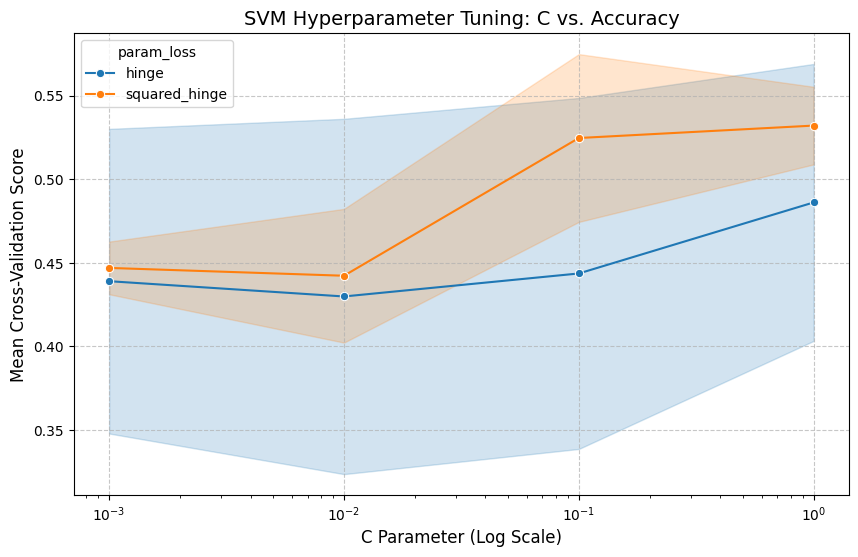

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your fitted GridSearchCV object for SVM is named 'grid_svm'
results_df = pd.DataFrame(svm_grid.cv_results_)

# 1. Create a clean tabular summary
svm_summary = results_df[['param_C', 'param_loss', 'param_class_weight', 'mean_test_score', 'rank_test_score']]
svm_summary = svm_summary.sort_values(by='rank_test_score')
print("Top 5 SVM Configurations:")
print(svm_summary.head(5))

# 2. Visualize the tuning comparison for the slide deck
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='param_C', y='mean_test_score', hue='param_loss', marker='o')
plt.xscale('log') # Log scale is best for C parameters (0.01 to 100)
plt.title('SVM Hyperparameter Tuning: C vs. Accuracy', fontsize=14)
plt.xlabel('C Parameter (Log Scale)', fontsize=12)
plt.ylabel('Mean Cross-Validation Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save directly for your presentation
plt.savefig('svm_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 20. Model 3: Logistic Regression
In this section, we train a **Logistic Regression** classifier using the same TF-IDF features.  
Logistic Regression is a strong linear baseline for multi-class text classification and is often competitive with SVM.

**Expected output:**  
Validation performance metrics and a classification report for the Logistic Regression model.


In [26]:
# Train and evaluate Logistic Regression
logistic_regression_model = LogisticRegression(
    max_iter=3000,
    n_jobs=-1,
    class_weight="balanced"
)

evaluate_model(
    model_name="Logistic Regression",
    model=logistic_regression_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)


Results for Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.4729
Precision: 0.5833
Recall   : 0.4729
F1-score : 0.5001
Macro F1 : 0.3602

Classification Report:

              precision    recall  f1-score   support

      action       0.32      0.46      0.38       263
       adult       0.38      0.75      0.50       118
   adventure       0.22      0.37      0.27       155
   animation       0.18      0.30      0.22       100
   biography       0.05      0.15      0.07        53
      comedy       0.60      0.45      0.51      1490
       crime       0.13      0.31      0.18       101
 documentary       0.79      0.56      0.65      2619
       drama       0.71      0.38      0.49      2723
      family       0.16      0.35      0.22       157
     fantasy       0.09      0.20      0.12        65
   game-show       0.67      0.72      0.69        39
     history       0.09      0.33      0.14        49
      horror       0.59  

## 20A. Hyperparameter Tuning for Logistic Regression

In [27]:
lr_param_grid = {
'C': [0.001, 0.01, 0.1, 1.0], # Lower values force a simpler, less overfit model
    'class_weight': [None, 'balanced'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(n_jobs=-1),
    param_grid=lr_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_tfidf, y_train)

best_lr_model = lr_grid.best_estimator_

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV Accuracy:", lr_grid.best_score_)

evaluate_model(
    model_name="Tuned Logistic Regression",
    model=best_lr_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best LR Params: {'C': 1.0, 'class_weight': None, 'max_iter': 1000, 'solver': 'lbfgs'}
Best LR CV Accuracy: 0.5709344954001523
Results for Tuned Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.5853
Precision: 0.5638
Recall   : 0.5853
F1-score : 0.5414
Macro F1 : 0.2755

Classification Report:

              precision    recall  f1-score   support

      action       0.56      0.27      0.36       263
       adult       0.77      0.29      0.42       118
   adventure       0.69      0.14      0.24       155
   animation       0.45      0.05      0.09       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.60      0.56      1490
       crime       0.25      0.01      0.02       101
 documentary       0.66      0.86      0.75      2619
       drama       0.54      0.78      0.64      2723
      family       0.55      0.08      0.13     

# 21. Model 4: Voting Ensemble
In this section, we build a **Voting Ensemble** using the previously selected base models:
- Naive Bayes
- Linear SVM
- Logistic Regression

A **hard voting** strategy is used, where each model votes for a class and the final prediction is chosen by majority vote.

**Expected output:**  
Validation performance metrics and a classification report for the Voting Ensemble model.


In [28]:
voting_ensemble_model = VotingClassifier(
    estimators=[
        ("nb", best_nb_model),
        ("svm", best_svm_model),
        ("lr", best_lr_model)
    ],
    voting="hard",
    n_jobs=-1
)

evaluate_model(
    model_name="Tuned Voting Ensemble",
    model=voting_ensemble_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Tuned Voting Ensemble
----------------------------------------------------------------------
Accuracy : 0.5901
Precision: 0.5609
Recall   : 0.5901
F1-score : 0.5452
Macro F1 : 0.2905

Classification Report:

              precision    recall  f1-score   support

      action       0.52      0.30      0.38       263
       adult       0.72      0.31      0.43       118
   adventure       0.60      0.17      0.26       155
   animation       0.41      0.07      0.12       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.60      0.57      1490
       crime       0.25      0.01      0.02       101
 documentary       0.65      0.87      0.75      2619
       drama       0.55      0.78      0.65      2723
      family       0.72      0.08      0.15       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.56      0.72        39
     history       0.00      0.00      0.00        49
      horror       0.66

# 22. Model Comparison
After evaluating all four methods, we compare them in a single summary table.  
This makes it easier to identify which model performed best on the validation set.

We also visualize the comparison and display a confusion matrix for the best model.


In [29]:
# Create a summary table of model performance
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values(by=["Accuracy", "F1-score"], ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,Macro F1
0,Tuned Voting Ensemble,0.590058,0.560859,0.590058,0.545192,0.290497
1,Tuned Linear SVM,0.586554,0.556582,0.586554,0.539494,0.291046
2,Tuned Logistic Regression,0.585262,0.563781,0.585262,0.541395,0.275527
3,Tuned Naive Bayes,0.568293,0.532713,0.568293,0.539494,0.300253
4,Naive Bayes,0.540533,0.519447,0.540533,0.468250,0.184988
5,Linear SVM,0.510652,0.556599,0.510652,0.524324,0.346834
6,Logistic Regression,0.472932,0.583303,0.472932,0.500148,0.360194


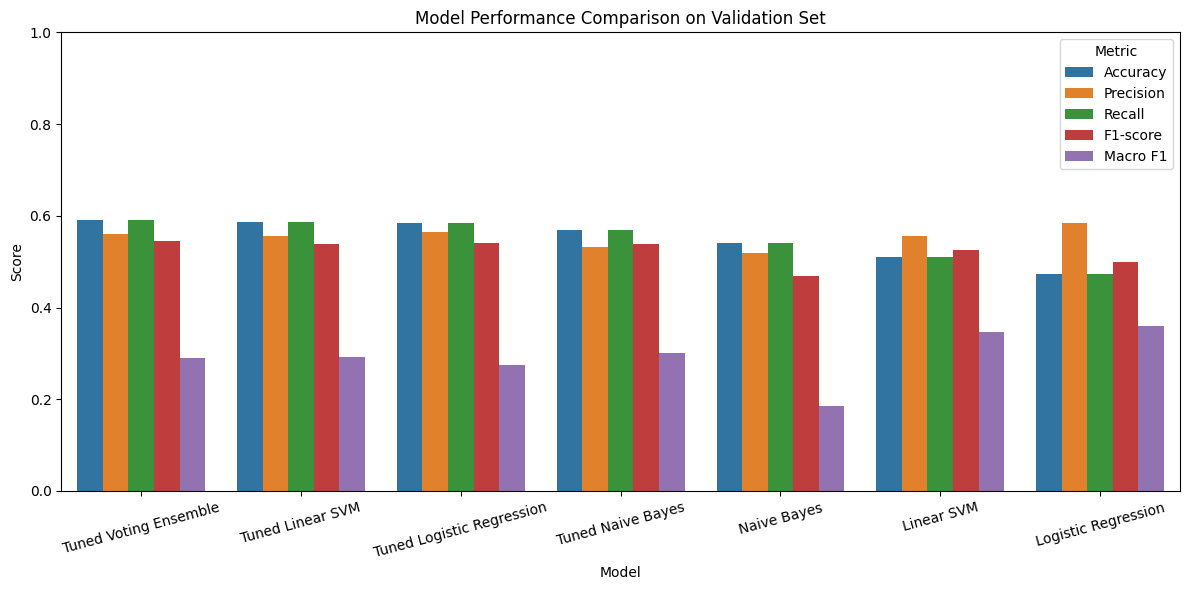

Highest validation accuracy: Tuned Voting Ensemble


In [30]:
# Plot model comparison across the main evaluation metrics
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison on Validation Set")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_accuracy_model_name = results_df.loc[0, "Model"]
print("Highest validation accuracy:", best_accuracy_model_name)


## 22A. Final Model Selection Rationale

Because the dataset is imbalanced, the final model should not be selected using validation accuracy alone.  
Instead, we use the following rule:

- **Primary criterion:** Weighted F1-score
- **Secondary criterion:** Macro F1-score
- **Tie-breaker:** Accuracy

This gives higher priority to models that perform well across both frequent and infrequent genres.


In [31]:
selection_df = (
    results_df
    .sort_values(by=["F1-score", "Macro F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

selected_final_model_name = selection_df.loc[0, "Model"]
selected_final_model_reason = (
    f"{selected_final_model_name} was selected as the final model because it achieved the highest "
    "validation weighted F1-score among the main candidate models. Macro F1-score was also considered "
    "because the dataset is imbalanced, so the final choice reflects a better trade-off than choosing "
    "the highest-accuracy model alone."
)

display(selection_df[["Model", "Accuracy", "F1-score", "Macro F1"]])
print("Selected final model:", selected_final_model_name)
print(selected_final_model_reason)


,Model,Accuracy,F1-score,Macro F1
0,Tuned Voting Ensemble,0.590058,0.545192,0.290497
1,Tuned Logistic Regression,0.585262,0.541395,0.275527
2,Tuned Naive Bayes,0.568293,0.539494,0.300253
3,Tuned Linear SVM,0.586554,0.539494,0.291046
4,Linear SVM,0.510652,0.524324,0.346834
5,Logistic Regression,0.472932,0.500148,0.360194
6,Naive Bayes,0.540533,0.468250,0.184988


Selected final model: Tuned Voting Ensemble
Tuned Voting Ensemble was selected as the final model because it achieved the highest validation weighted F1-score among the main candidate models. Macro F1-score was also considered because the dataset is imbalanced, so the final choice reflects a better trade-off than choosing the highest-accuracy model alone.


## 22B. Verify Official Test Labels
Before final testing, we verify the structure of the official test labels.


In [32]:
print(test_solution_df.head())
print(test_solution_df.shape)

  ID                                              Genre
0  1  Edgar's Lunch (1998) ::: thriller ::: L.R. Bra...
1  2  La guerra de papÃ¡ (1977) ::: comedy ::: Spain...
2  3  Off the Beaten Track (2010) ::: documentary ::...
3  4  Meu Amigo Hindu (2015) ::: drama ::: His fathe...
4  5  Er nu zhai (1955) ::: drama ::: Before he was ...
(54200, 2)


# 23. Final Evaluation on the Official Test Set
The dataset provides `test_data_solution.txt`, which contains the true labels for the test set.  
The final model is selected using **validation weighted F1-score** as the primary criterion and **Macro F1-score** as a secondary criterion, because the dataset is imbalanced and accuracy alone can be misleading.

After selecting the final model, we retrain it on the full training data and evaluate it on the official test set. This gives a more realistic estimate of how well the chosen configuration generalizes to unseen examples.


In [33]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Select the final model using imbalance-aware validation criteria
selection_df = (
    results_df
    .sort_values(by=["F1-score", "Macro F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
selected_final_model_name = selection_df.loc[0, "Model"]
selected_final_model_reason = (
    "The final model was selected using validation weighted F1-score as the primary criterion "
    "and Macro F1-score as the secondary criterion because the dataset is imbalanced. "
    f"Based on this rule, {selected_final_model_name} was selected instead of choosing the model "
    "with the highest accuracy only."
)

# Merge the test descriptions with their official labels
official_test_df = test_df.merge(test_solution_df, on="ID", how="inner")

official_test_df["Genre"] = (
    official_test_df["Genre"]
    .astype(str)
    .str.extract(r":::\s*([a-zA-Z\-]+)\s*:::", expand=False)
    .str.strip()
    .str.lower()
)

# Clean text and labels
train_df["Genre"] = train_df["Genre"].astype(str).str.strip().str.lower()
official_test_df["Clean_Title"] = official_test_df["Title"].apply(clean_text)
official_test_df["Clean_Description"] = official_test_df["Description"].apply(clean_text)
official_test_df["Full_Text"] = official_test_df["Clean_Title"] + " " + official_test_df["Clean_Description"]

X_full_train = train_df["Full_Text"].fillna("")
y_full_train = train_df["Genre"]
X_test_official = official_test_df["Full_Text"].fillna("")
y_test_official = official_test_df["Genre"]

# Use the same validated TF-IDF configuration as the main baseline experiments
final_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    max_features=50000
)

X_full_train_tfidf = final_vectorizer.fit_transform(X_full_train)
X_test_official_tfidf = final_vectorizer.transform(X_test_official)

if selected_final_model_name == "Naive Bayes":
    final_model = MultinomialNB(alpha=0.5)
elif selected_final_model_name == "Tuned Naive Bayes":
    final_model = best_nb_model
elif selected_final_model_name == "Linear SVM":
    final_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000)
elif selected_final_model_name == "Tuned Linear SVM":
    final_model = best_svm_model
elif selected_final_model_name == "Logistic Regression":
    final_model = LogisticRegression(max_iter=3000, n_jobs=-1, class_weight="balanced")
elif selected_final_model_name == "Tuned Logistic Regression":
    final_model = best_lr_model
elif selected_final_model_name == "Tuned Voting Ensemble":
    final_model = VotingClassifier(
        estimators=[
            ("nb", best_nb_model),
            ("svm", best_svm_model),
            ("lr", best_lr_model)
        ],
        voting="hard",
        n_jobs=-1
    )
else:
    raise ValueError(f"Unknown model name: {selected_final_model_name}")

# Train and evaluate
final_model.fit(X_full_train_tfidf, y_full_train)
train_predictions = final_model.predict(X_full_train_tfidf)
test_predictions = final_model.predict(X_test_official_tfidf)

train_accuracy = accuracy_score(y_full_train, train_predictions)
test_accuracy = accuracy_score(y_test_official, test_predictions)
train_f1 = f1_score(y_full_train, train_predictions, average="weighted")
test_f1 = f1_score(y_test_official, test_predictions, average="weighted")
gap = train_accuracy - test_accuracy
final_test_classification_report = classification_report(y_test_official, test_predictions, zero_division=0)

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)
print(f"Selected Model  : {selected_final_model_name}")
print(f"Train Accuracy  : {train_accuracy:.2%}")
print(f"Train F1 Score  : {train_f1:.2%}")
print(f"Test Accuracy   : {test_accuracy:.2%}")
print(f"Test F1 Score   : {test_f1:.2%}")
print(f"Generalization Gap (Accuracy): {gap:.2%}")
print("=" * 60)
print(selected_final_model_reason)

print("\nSample predictions:")
print(pd.Series(test_predictions).head())


FINAL MODEL RESULTS
Selected Model  : Tuned Voting Ensemble
Train Accuracy  : 72.30%
Train F1 Score  : 68.74%
Test Accuracy   : 59.40%
Test F1 Score   : 54.25%
Generalization Gap (Accuracy): 12.90%
The final model was selected using validation weighted F1-score as the primary criterion and Macro F1-score as the secondary criterion because the dataset is imbalanced. Based on this rule, Tuned Voting Ensemble was selected instead of choosing the model with the highest accuracy only.

Sample predictions:
0          drama
1          drama
2    documentary
3          drama
4          drama
dtype: object


## 23A. Confusion Matrix Analysis

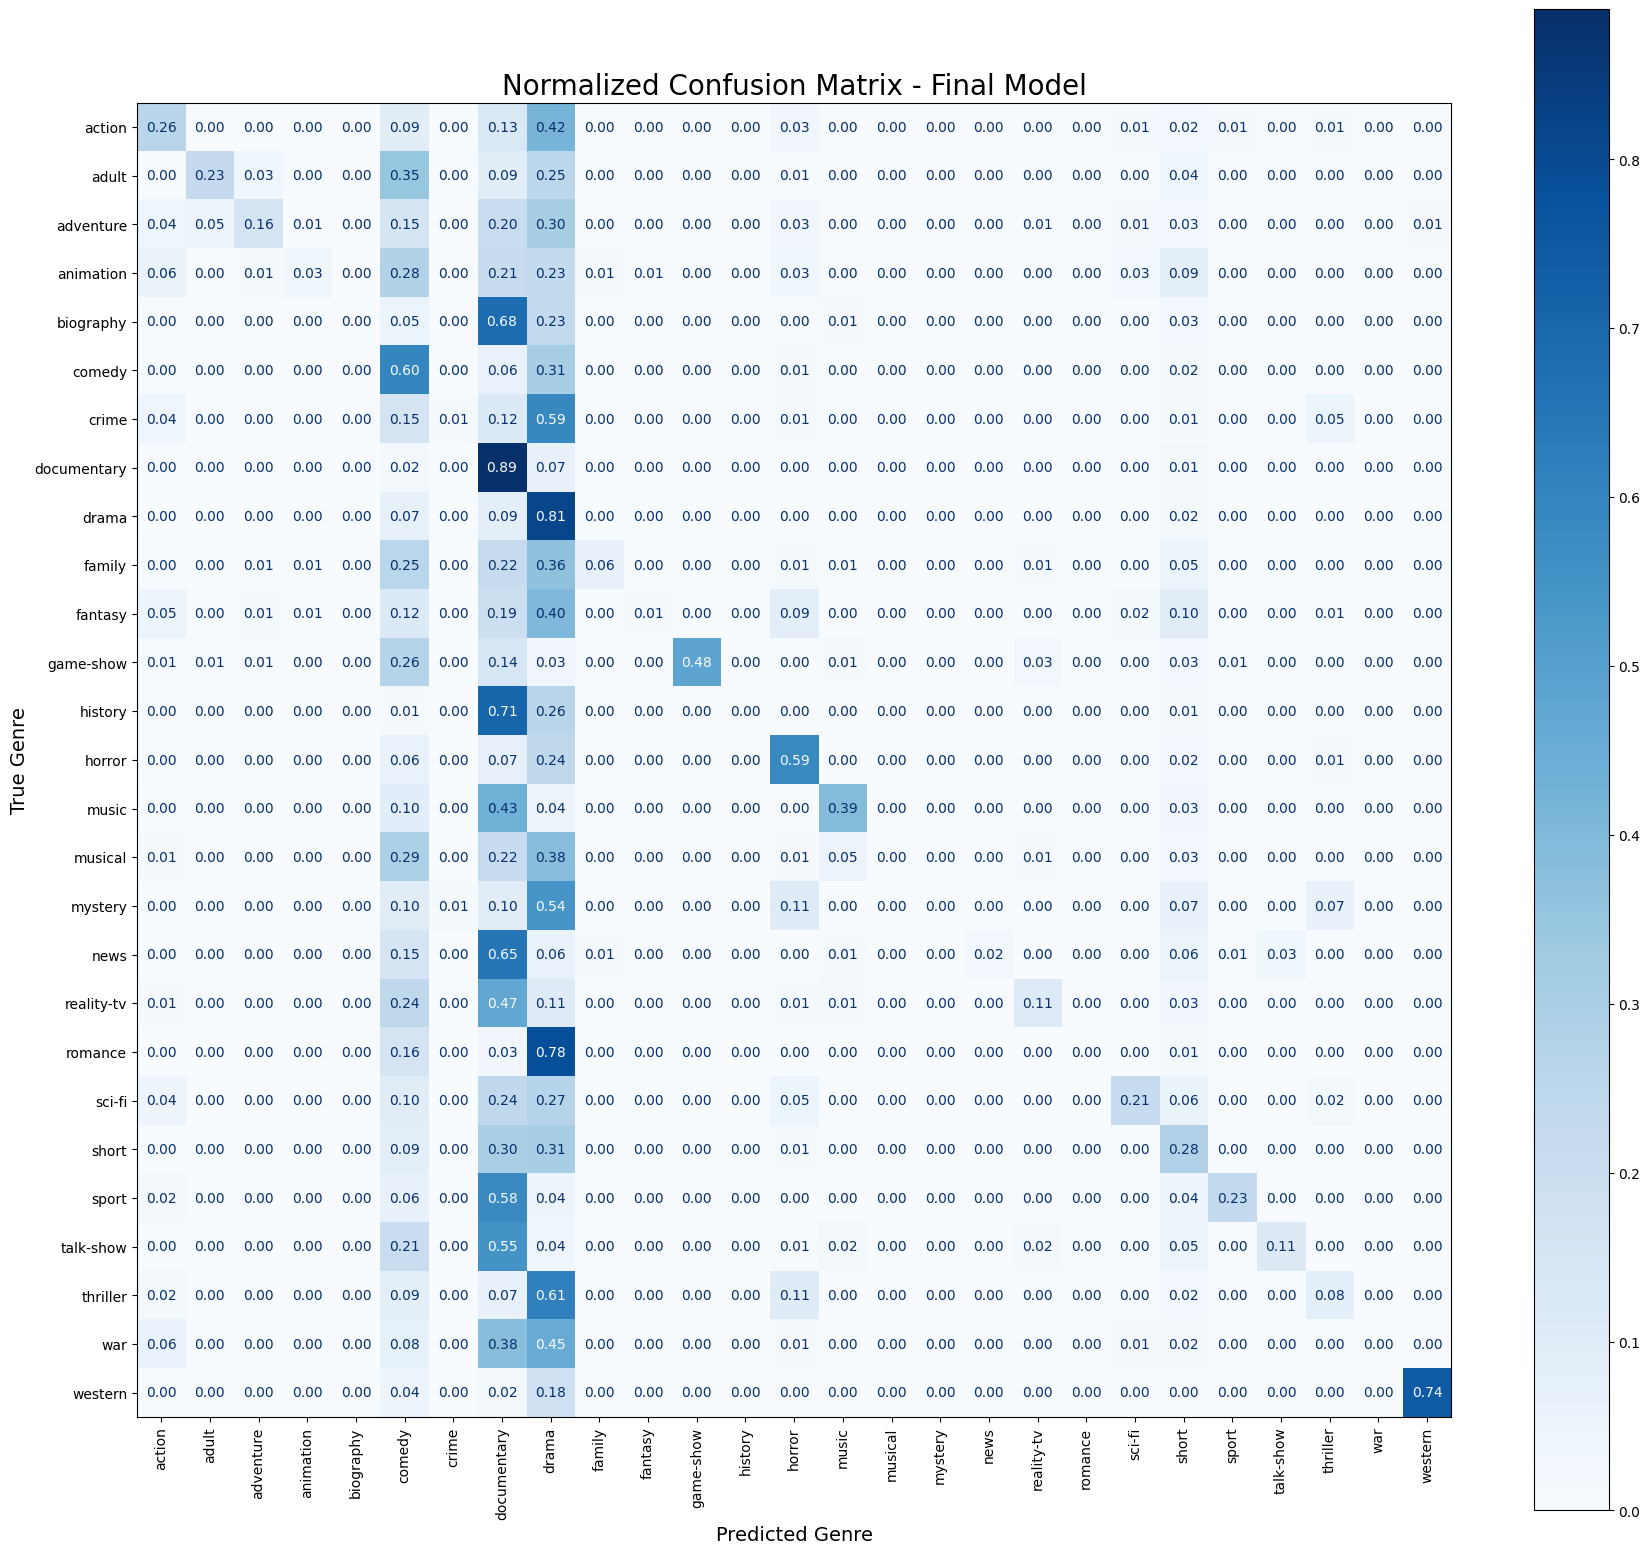

In [34]:

# Normalized confusion matrix
cm = confusion_matrix(
    y_test_official,
    test_predictions,
    labels=final_model.classes_,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(18, 16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=90,
    colorbar=True,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix - Final Model", fontsize=20)
plt.xlabel("Predicted Genre", fontsize=14)
plt.ylabel("True Genre", fontsize=14)

plt.tight_layout()
plt.show()

This Figure presents the confusion matrix for the best-performing model on the official test set. The matrix illustrates the relationship between the true movie genres and the predicted genres produced by the classifier.

The diagonal values represent correctly classified samples, while off-diagonal values indicate misclassifications between genres. The results show that the model performs particularly well on majority classes such as drama, documentary, and comedy, where a large number of samples were correctly identified.

However, lower performance can be observed for minority genres such as biography, history, and fantasy. In several cases, these genres were misclassified as more dominant categories due to overlapping vocabulary and the imbalance in class distribution.

The confusion matrix also highlights semantic similarities between certain genres. For example, some drama-related genres were confused with comedy or documentary because movie plot summaries may share similar textual patterns and descriptive language.

Overall, the confusion matrix provides a deeper understanding of model behavior beyond accuracy and F1-score, helping identify which genres are easier or more difficult for the classifier to distinguish.

## 23B. Learning Curve Analysis

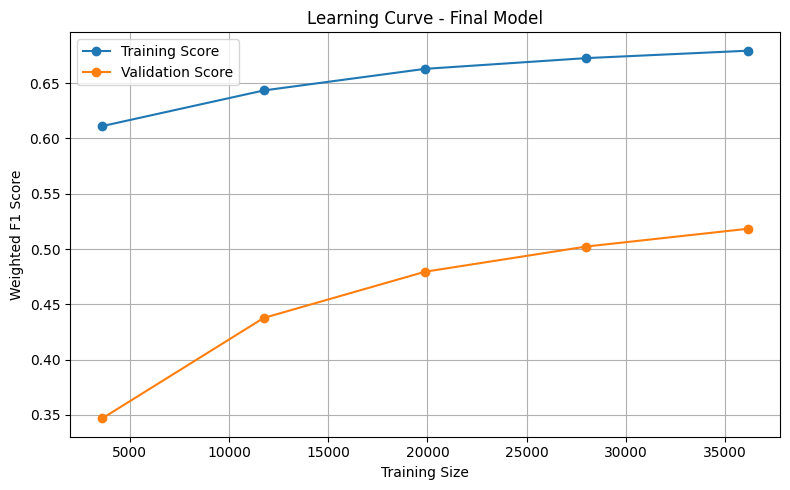

In [36]:
from sklearn.model_selection import learning_curve
# Learning Curve for the selected final model
train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_model,
    X=X_full_train_tfidf,
    y=y_full_train,
    cv=3,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Weighted F1 Score")
plt.title("Learning Curve - Final Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The learning curve shows that the validation Weighted F1-score improves steadily as the training size increases, indicating that the model benefits from additional training examples and continues to learn meaningful patterns from the data.

Although a gap remains between the training and validation scores, the validation performance consistently increases with larger training sizes, suggesting that the model is generalizing reasonably well rather than completely memorizing the training data.

The remaining gap can be attributed to several challenges within the dataset, including class imbalance, overlapping genre boundaries, and the high variability of movie plot writing styles. Overall, the learning curve confirms that the selected model achieves stable learning behavior and that additional balanced data could further improve generalization performance.

## 24. Final Conclusion

This notebook addressed movie genre classification from plot summaries as a multi-class supervised text classification problem.

After performing exploratory data analysis and preprocessing, the cleaned movie titles and plot summaries were combined and transformed into TF-IDF feature vectors. We then trained and compared four machine learning methods:

1. Naive Bayes  
2. Support Vector Machine (SVM)  
3. Logistic Regression  
4. Voting Ensemble  

To improve performance, we also applied hyperparameter tuning. Naive Bayes, Linear SVM, and Logistic Regression were tuned using GridSearchCV by testing different parameter combinations, such as the smoothing parameter for Naive Bayes and the regularization strength for SVM and Logistic Regression.

The best-performing configuration on the validation set was the Tuned Voting Ensemble, which achieved the highest weighted F1-score among the main candidate models. Since the dataset is imbalanced, weighted F1-score was used as the primary selection criterion, while Macro F1-score was used as a secondary criterion. This selection strategy helps avoid relying on accuracy alone, which can be misleading when some genres appear much more frequently than others.

The Tuned Voting Ensemble combined the strengths of Naive Bayes, Linear SVM, and Logistic Regression. This allowed the final model to benefit from different learning behaviors: Naive Bayes captures probabilistic word patterns, SVM provides strong margin-based classification, and Logistic Regression contributes stable linear decision-making. Although Tuned Logistic Regression and Tuned Linear SVM achieved competitive results, the ensemble produced the strongest overall validation performance.

In the final evaluation on the official test set, the selected model was retrained on the full training data and tested on unseen examples. This provides a more realistic estimate of generalization performance.

Although the final model achieved reasonable performance, a gap between training and test performance remained. This indicates that movie genre classification from plot summaries is still challenging due to class imbalance, overlapping genre boundaries, and variability in writing style. Many genres share similar vocabulary, such as drama, romance, comedy, and thriller, which makes accurate classification difficult even after preprocessing and tuning.

Overall, the project demonstrates that traditional machine learning models combined with TF-IDF features are effective for movie genre classification tasks. Among the evaluated approaches, the Tuned Voting Ensemble achieved the best overall balance and validation performance by combining the strengths of multiple classifiers.


# 25. Enhancement Plan: Richer N-grams and Better Imbalance Handling

The preliminary results suggest two practical improvements:

1. **Richer feature representation** using word **n-grams**, especially extending from the current setup to include **tri-grams**.
2. **Better handling of class imbalance** using **class weighting** and evaluating models with **weighted F1** and **macro F1**, not accuracy alone.

> **Important note:** this notebook already uses **bi-grams** through `ngram_range=(1, 2)`.  
> Therefore, the next-step improvement is best presented as **expanding the representation from uni+bi-grams to uni+bi+tri-grams**, then checking whether minority-class performance improves.


## 25A. Re-rank Existing Models Using F1-Based Selection

Because the dataset is imbalanced, **accuracy alone can be misleading**.  
In this section, we re-rank the previously trained models using:

- **Weighted F1-score** as the primary selection metric
- **Macro F1-score** as a secondary metric to reflect minority-class performance


In [37]:
results_by_f1 = (
    results_df
    .sort_values(by=["F1-score", "Macro F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Model ranking when class imbalance is considered:")
display(results_by_f1)

best_f1_model_name = results_by_f1.loc[0, "Model"]
print("\nBest model based on Weighted F1, then Macro F1:", best_f1_model_name)



Model ranking when class imbalance is considered:


,Model,Accuracy,Precision,Recall,F1-score,Macro F1
0,Tuned Voting Ensemble,0.590058,0.560859,0.590058,0.545192,0.290497
1,Tuned Logistic Regression,0.585262,0.563781,0.585262,0.541395,0.275527
2,Tuned Naive Bayes,0.568293,0.532713,0.568293,0.539494,0.300253
3,Tuned Linear SVM,0.586554,0.556582,0.586554,0.539494,0.291046
4,Linear SVM,0.510652,0.556599,0.510652,0.524324,0.346834
5,Logistic Regression,0.472932,0.583303,0.472932,0.500148,0.360194
6,Naive Bayes,0.540533,0.519447,0.540533,0.468250,0.184988



Best model based on Weighted F1, then Macro F1: Tuned Voting Ensemble


## 25B. Compare Different N-gram Ranges

This experiment compares several TF-IDF feature configurations using the selected Voting Ensemble model to examine whether richer n-gram representations improve genre classification performance.

The goal is to check whether adding **tri-grams** improves genre recognition by capturing richer local context.

We compare:
- **Unigrams only** `(1, 1)`
- **Unigrams + Bigrams** `(1, 2)`
- **Unigrams + Bigrams + Trigrams** `(1, 3)`


In [41]:
def evaluate_text_pipeline(model_name, pipeline, X_train, y_train, X_valid, y_valid):

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_valid)

    row = {

        "Model": model_name,

        "Accuracy": accuracy_score(y_valid, preds),

        "Weighted F1": f1_score(y_valid, preds, average="weighted", zero_division=0),

        "Macro F1": f1_score(y_valid, preds, average="macro", zero_division=0)

    }

    return row, preds

ngram_experiments = []

ngram_predictions = {}

for ngram_range in [(1, 1), (1, 2), (1, 3)]:

    pipeline = Pipeline([

        ("tfidf", TfidfVectorizer(

            stop_words="english",

            ngram_range=ngram_range,

            min_df=3,

            max_df=0.9,

            sublinear_tf=True,

            max_features=70000

        )),

        ("clf", VotingClassifier(

            estimators=[

                ("nb", MultinomialNB(alpha=1.0, fit_prior=False)),

                ("svm", LinearSVC(

                    C=0.1,

                    loss="squared_hinge",

                    max_iter=2000

                )),

                ("lr", LogisticRegression(

                    C=1.0,

                    max_iter=1000,

                    solver="liblinear"

                ))

            ],

            voting="hard",

            n_jobs=-1

        ))

    ])

    row, preds = evaluate_text_pipeline(

        model_name=f"TF-IDF {ngram_range} + Voting Ensemble",

        pipeline=pipeline,

        X_train=X_train,

        y_train=y_train,

        X_valid=X_valid,

        y_valid=y_valid

    )

    ngram_experiments.append(row)

    ngram_predictions[row["Model"]] = preds

ngram_results_df = pd.DataFrame(ngram_experiments).sort_values(

    by=["Weighted F1", "Macro F1", "Accuracy"],

    ascending=False

).reset_index(drop=True)

ngram_results_df

,Model,Accuracy,Weighted F1,Macro F1
0,"TF-IDF (1, 1) + Voting Ensemble",0.581850,0.526497,0.248525
1,"TF-IDF (1, 2) + Voting Ensemble",0.579083,0.520925,0.237445
2,"TF-IDF (1, 3) + Voting Ensemble",0.578622,0.520623,0.238307


## 25C. Visualize the N-gram Comparison

If tri-grams improve **Weighted F1** or **Macro F1**, you can claim that richer phrase-level context helps the model distinguish genres more effectively.


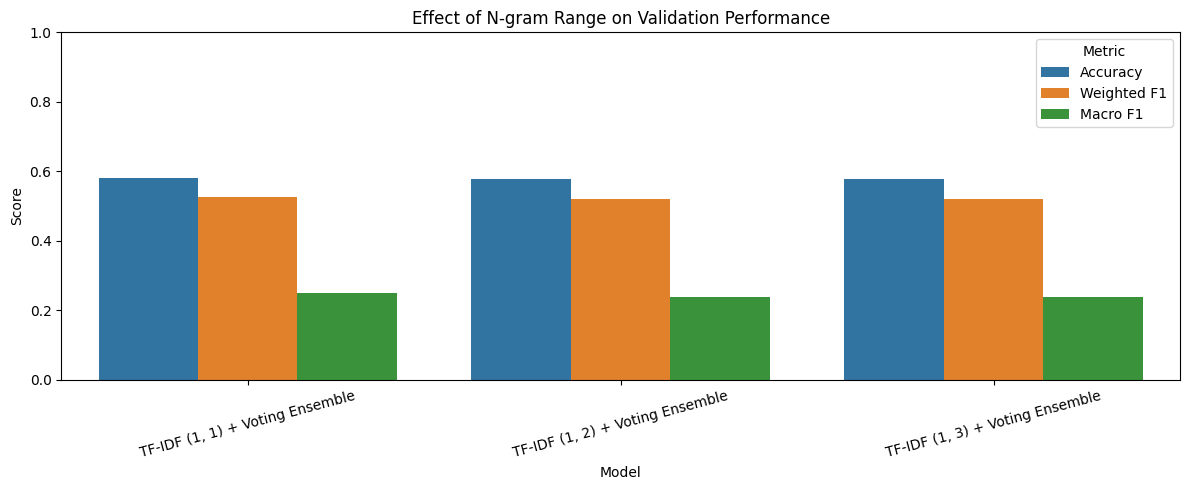

Best feature representation: TF-IDF (1, 1) + Voting Ensemble


In [42]:
plot_ngram_df = ngram_results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_ngram_df, x="Model", y="Score", hue="Metric")
plt.title("Effect of N-gram Range on Validation Performance")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_ngram_model_name = ngram_results_df.loc[0, "Model"]
print("Best feature representation:", best_ngram_model_name)


## 26. Class Weighting Analysis with the Voting Ensemble

In the earlier experiments, class weighting (None vs balanced) was already examined during model tuning.

After extending the TF-IDF representation from (1,2) to (1,3), we re-evaluate whether class weighting becomes more useful under the richer feature space, especially for minority genres.

The comparison is assessed mainly using Macro F1-score and minority-class results.

In [43]:
imbalance_experiments = []
imbalance_predictions = {}

for class_weight in [None, "balanced"]:
    label = "balanced" if class_weight == "balanced" else "no weighting"

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 3),
            min_df=3,
            max_df=0.9,
            sublinear_tf=True,
            max_features=70000
        )),
        ("clf", VotingClassifier(
            estimators=[
                ("nb", MultinomialNB(alpha=1.0, fit_prior=False)),
                ("svm", LinearSVC(
                    C=0.1,
                    loss="squared_hinge",
                    class_weight=class_weight,
                    max_iter=2000
                )),
                ("lr", LogisticRegression(
                    C=1.0,
                    class_weight=class_weight,
                    max_iter=1000,
                    solver="liblinear"
                ))
            ],
            voting="hard",
            n_jobs=-1
        ))
    ])

    row, preds = evaluate_text_pipeline(
        model_name=f"Voting Ensemble ({label}) with TF-IDF (1,3)",
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        X_valid=X_valid,
        y_valid=y_valid
    )

    imbalance_experiments.append(row)
    imbalance_predictions[row["Model"]] = preds

imbalance_results_df = pd.DataFrame(imbalance_experiments).sort_values(
    by=["Macro F1", "Weighted F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

imbalance_results_df

,Model,Accuracy,Weighted F1,Macro F1
0,"Voting Ensemble (balanced) with TF-IDF (1,3)",0.562390,0.559410,0.400220
1,"Voting Ensemble (no weighting) with TF-IDF (1,3)",0.578622,0.520623,0.238307


## 26A. Inspect Minority-Class Performance

This table focuses on the genres that have the smallest number of validation examples.  
It helps determine whether class weighting improves recall and F1-score for minority classes.


In [44]:
minority_classes = y_valid.value_counts().sort_values().head(10).index.tolist()

minority_tables = []
for model_name, preds in imbalance_predictions.items():
    report_dict = classification_report(y_valid, preds, output_dict=True, zero_division=0)
    temp = pd.DataFrame(report_dict).T
    temp = temp.loc[minority_classes, ["precision", "recall", "f1-score", "support"]].copy()
    temp["Model"] = model_name
    temp["Genre"] = temp.index
    minority_tables.append(temp.reset_index(drop=True))

minority_comparison_df = pd.concat(minority_tables, ignore_index=True)
minority_comparison_df = minority_comparison_df[["Model", "Genre", "precision", "recall", "f1-score", "support"]]
minority_comparison_df.sort_values(by=["Genre", "Model"]).head(30)


,Model,Genre,precision,recall,f1-score,support
14,"Voting Ensemble (balanced) with TF-IDF (1,3)",biography,0.050000,0.037736,0.043011,53.0
4,"Voting Ensemble (no weighting) with TF-IDF (1,3)",biography,0.000000,0.000000,0.000000,53.0
17,"Voting Ensemble (balanced) with TF-IDF (1,3)",fantasy,0.181818,0.184615,0.183206,65.0
7,"Voting Ensemble (no weighting) with TF-IDF (1,3)",fantasy,0.000000,0.000000,0.000000,65.0
12,"Voting Ensemble (balanced) with TF-IDF (1,3)",game-show,0.742857,0.666667,0.702703,39.0
2,"Voting Ensemble (no weighting) with TF-IDF (1,3)",game-show,1.000000,0.307692,0.470588,39.0
13,"Voting Ensemble (balanced) with TF-IDF (1,3)",history,0.204545,0.183673,0.193548,49.0
3,"Voting Ensemble (no weighting) with TF-IDF (1,3)",history,0.000000,0.000000,0.000000,49.0
15,"Voting Ensemble (balanced) with TF-IDF (1,3)",musical,0.200000,0.236364,0.216667,55.0
5,"Voting Ensemble (no weighting) with TF-IDF (1,3)",musical,0.000000,0.000000,0.000000,55.0


## 30. Libraries and Computational Resources

> The experiments were implemented in Python using **pandas, NumPy, scikit-learn, Matplotlib, and Seaborn**. The models are classical machine learning models from scikit-learn and were trained in a notebook environment using **CPU-based computation**.


In [46]:
import sys
import os
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("CPU cores available:", os.cpu_count())
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Python version: 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Processor: x86_64
CPU cores available: 2
NumPy version: 2.0.2
pandas version: 2.2.2
scikit-learn version: 1.6.1
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
